## Sales Prediction Using Python

**Objective:** Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Feature Checklist:**
- Download a suitable dataset (see Self-Sourcing Guideline below)
- Data loading and EDA: null check, descriptive statistics, pairplot of all features
- Individual scatter plots: Sales vs. TV spend, Sales vs. Radio spend, Sales vs. Newspaper spend
- Correlation matrix heatmap
- Train/test split
- Train a Linear Regression model as the baseline
- Train at least one additional model (e.g., Random Forest Regressor, Polynomial Regression)
- Evaluate using: MAE, RMSE, R² score
- Residual plot for the best model (are errors randomly distributed or systematic?)
- Interpretation: which advertising channel has the highest impact on sales? (Answered using coefficients or feature importance)
- Clean, well-commented Jupyter Notebook

#### IMPORT THE LIBRARIES

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics
from scipy import stats

sns.set_style('whitegrid')

#### LOAD DATASET

In [2]:
# Load The Dataset
sp = pd.read_csv("Advertising.csv")

In [3]:
# Check the first five rows of the dataset
sp.head(5)

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Check the last five rows of the dataset
sp.tail(5)

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


#### DATA CLEANING AND INVESTIGATION

In [5]:
# Check the shape of the dataset
sp.shape

(200, 5)

In [6]:
# Check the null values of the dataset
sp.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [7]:
# Check the important information of the dataset set
sp.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
# Counting the number of unique values to identify redundant features
{x: len(sp[x].unique()) for x in  sp.columns}

{'Unnamed: 0': 200, 'TV': 190, 'radio': 167, 'newspaper': 172, 'sales': 121}

In [9]:
# Going through the statistical values in the dataset 
sp.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [10]:
# Drop the 'Unnamed: 0' column
sp = sp.drop('Unnamed: 0', axis=1)
sp.head(2)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4


#### EXPLORATORY DATA ANALYSIS

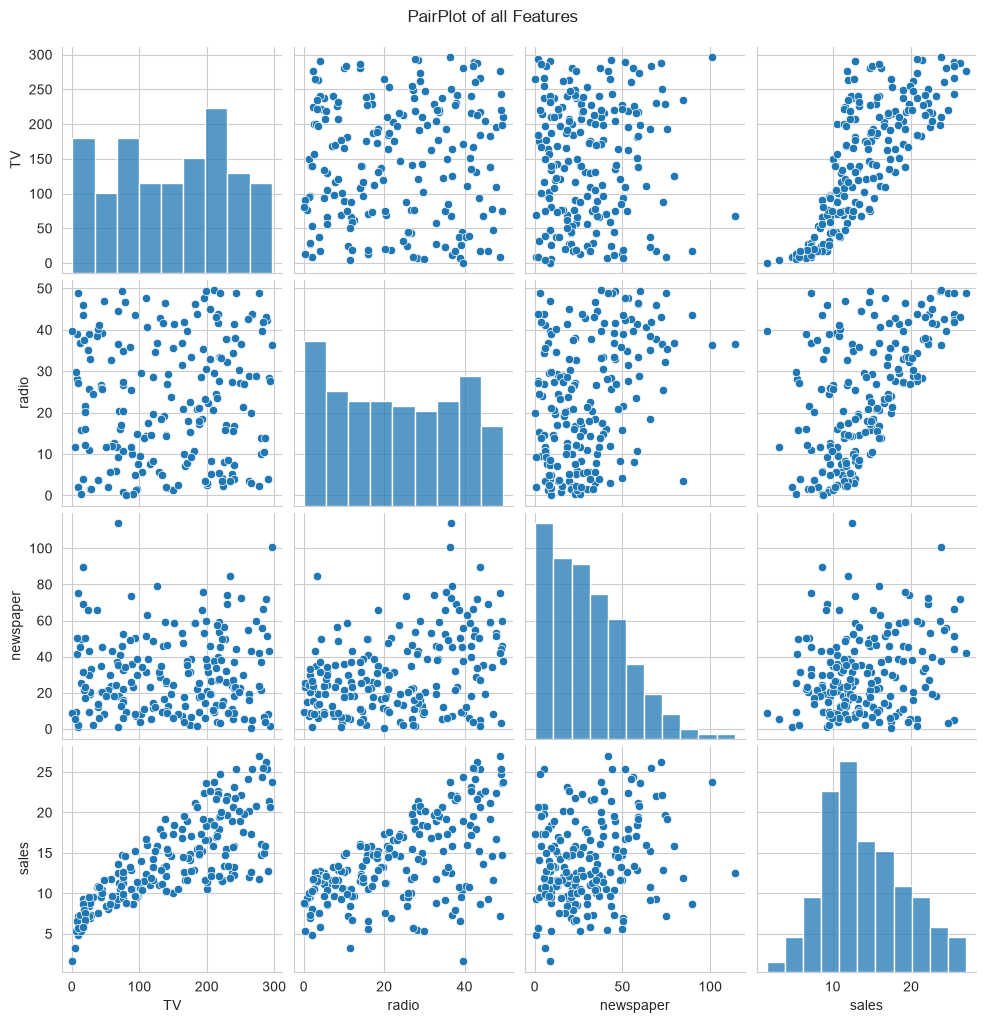

In [11]:
# pairplot of the features in the dataset
sns.pairplot(sp)
plt.suptitle('PairPlot of all Features', y=1.02)
plt.show()

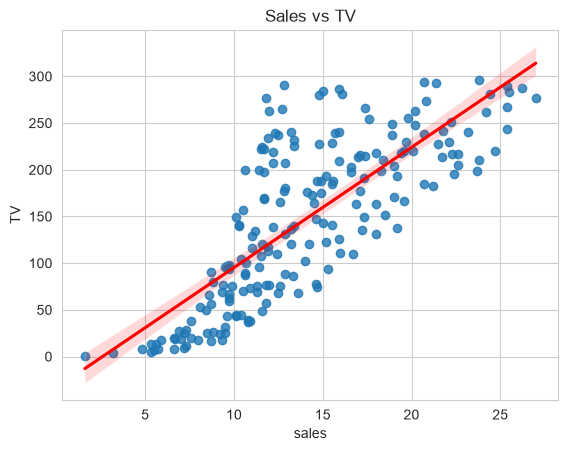

In [12]:
# Scatter plots between 'Sales' and 'TV'
sns.regplot(x='sales', y='TV', data=sp, line_kws={'color' : 'red'})
plt.xlabel('sales')
plt.ylabel('TV')
plt.title('Sales vs TV')
plt.show()

- This is a Positive Relationship. TV is a good platform to drive sales

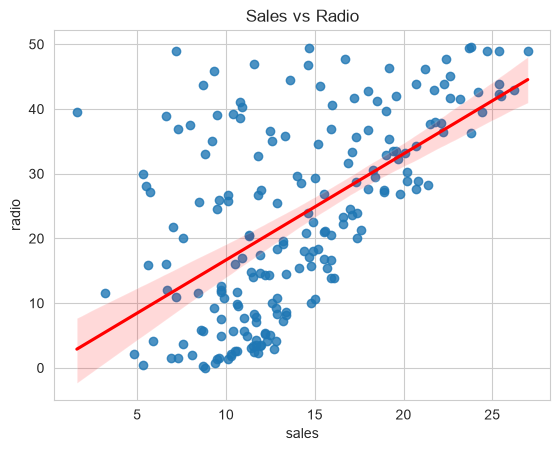

In [13]:
# Scatter plots between 'Sales' and 'Radio'
sns.regplot(x='sales', y='radio', data=sp, line_kws={'color' : 'red'})
plt.xlabel('sales')
plt.ylabel('radio')
plt.title('Sales vs Radio')
plt.show()

- This is a Positive Relationship. Radio is a good platform to drive sales

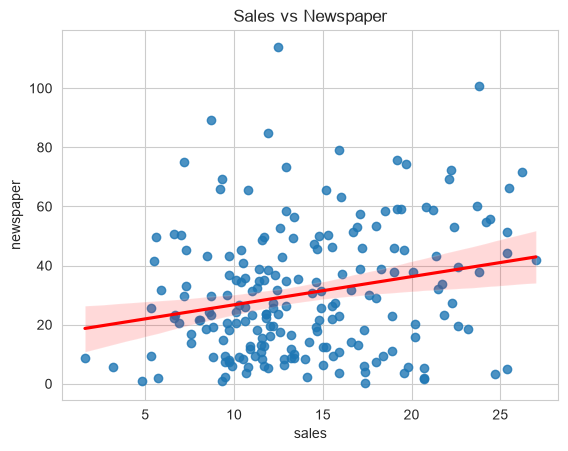

In [14]:
# Scatter plots between 'Sales' and 'Newspaper'
sns.regplot(x='sales', y='newspaper', data=sp, line_kws={'color' : 'red'})
plt.xlabel('sales')
plt.ylabel('newspaper')
plt.title('Sales vs Newspaper')
plt.show()

- This is a Weak or Linear Relationship. 
- This shows that Newspaper does not really drive sales 
or not a good platform to drive sales

#### FEATURE CORRELATION HEATMAP

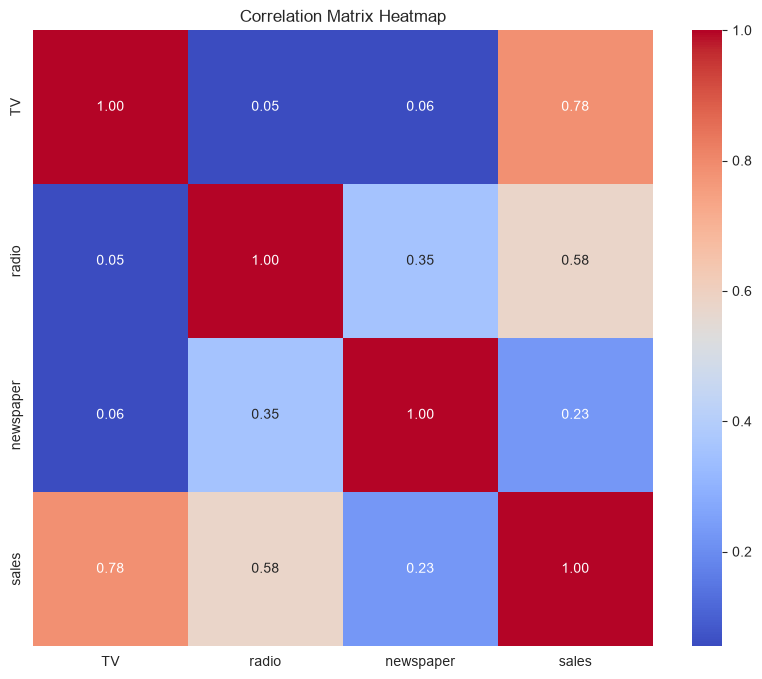

In [15]:
# Correlation matrix heatmap
correlation_matrix = sp.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

- The correlation between 'Sales' and'TV' has the highest at '0.75'.
- The correlation between 'Sales' and'Radio' has the second highest at '0.58'.
- While the correlation between 'Sales' and'Newspaper' has the lowest at '0.23'.

#### TRAIN TEST SPLIT

In [16]:
# Splitting the dataset into (x) and (y)
X = sp.drop('sales', axis= 1)
Y = sp['sales']

In [17]:
# Splitting the training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.1, random_state = 2)

### MODEL TRAINING

#### 1 LINEAR REGRESSION

In [18]:
# loading the Linear Regression model
Lin_model = LinearRegression()

In [19]:
# Fit the model
Lin_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','radio','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.933
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [20]:
# Predicton on the training data
Train_data_predict = Lin_model.predict(X_train)
Train_r2_lr = metrics.r2_score(Y_train, Train_data_predict)
Train_mae_lr = metrics.mean_absolute_error(Y_train, Train_data_predict)
Train_rmse_lr = np.sqrt(metrics.mean_squared_error(Y_train, Train_data_predict))

print('R2_score', Train_r2_lr)
print('Mae', Train_mae_lr)
print('Rmse', Train_rmse_lr)

R2_score 0.9025407988209102
Mae 1.2313125751926592
Rmse 1.6514899597264008


In [21]:
# Predicton on the testing data
Test_data_predict = Lin_model.predict(X_test)
Test_r2_lr = metrics.r2_score(Y_test, Test_data_predict)
Test_mae_lr = metrics.mean_absolute_error(Y_test, Test_data_predict)
Test_rmse_lr = np.sqrt(metrics.mean_squared_error(Y_test, Test_data_predict))

print('R2_score', Test_r2_lr)
print('Mae', Test_mae_lr)
print('Rmse', Test_rmse_lr)

R2_score 0.8169646763804372
Mae 1.35603701337094
Rmse 1.8238287394523394


#### 2 RANDOM FOREST REGRESSOR

In [22]:
# loading the Random Forest Regressor model
Ran_model = RandomForestRegressor(n_estimators = 100, random_state =2)

In [23]:
# Fit the model
Ran_model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",2
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [24]:
# Predicton on the training data
Train_data_predict = Ran_model.predict(X_train)
Train_r2_rfr = metrics.r2_score(Y_train, Train_data_predict)
Train_mae_rfr = metrics.mean_absolute_error(Y_train, Train_data_predict)
Train_rmse_rfr = np.sqrt(metrics.mean_squared_error(Y_train, Train_data_predict))

print('R2_score', Train_r2_rfr)
print('Mae', Train_mae_rfr)
print('Rmse', Train_rmse_rfr)

R2_score 0.9970886866992141
Mae 0.20558888888888882
Rmse 0.2854361574853471


In [25]:
# Predicton on the testing data
Test_data_predict = Ran_model.predict(X_test)
Test_r2_rfr = metrics.r2_score(Y_test, Test_data_predict)
Test_mae_rfr = metrics.mean_absolute_error(Y_test, Test_data_predict)
Test_rmse_rfr = np.sqrt(metrics.mean_squared_error(Y_test, Test_data_predict))

print('R2_score', Test_r2_rfr)
print('Mae', Test_mae_rfr)
print('Rmse', Test_rmse_rfr)

R2_score 0.9817697938318768
Mae 0.49185000000000006
Rmse 0.5755888723733279


#### MODEL COMPARISON TO KNOW BEST MODEL

In [26]:
# Model Comparison
print('MODEL', ':', 'R2_SCORE', ':', 'MAE', ':', 'RMSE')
print('Linear Regression', ':', Test_r2_lr, ':', Test_mae_lr, ':', Test_rmse_lr)
print('Random Forest Regressor', ':', Test_r2_rfr, ':', Test_mae_rfr, ':', Test_rmse_rfr)

MODEL : R2_SCORE : MAE : RMSE
Linear Regression : 0.8169646763804372 : 1.35603701337094 : 1.8238287394523394
Random Forest Regressor : 0.9817697938318768 : 0.49185000000000006 : 0.5755888723733279


- Random Forest Regressor is best performing model because it has the highest R² Score and lowest RMSE.

#### Residual Plot for the best model, "Random Forest Regressor"

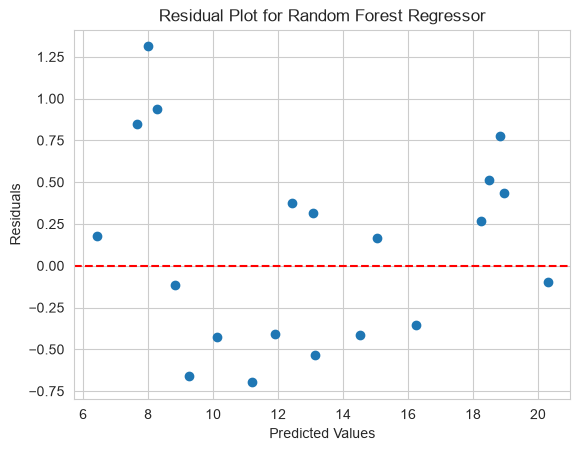

In [27]:
# Residual Plot for the best model, "Random Forest Regressor"
y_pred = Ran_model.predict(X_test)
residuals = Y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot for Random Forest Regressor')
plt.show()

- The points are scattered around "0" and are roughly random. There are no pattern and curves. 
- This suggests that the model's errors are random rather than systematic.

#### FEATURE IMPORTANCE FOR RANDOM FOREST REGRESSOR

In [28]:
# Feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': Ran_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

     Feature  Importance
0         TV    0.640213
1      radio    0.351833
2  newspaper    0.007953


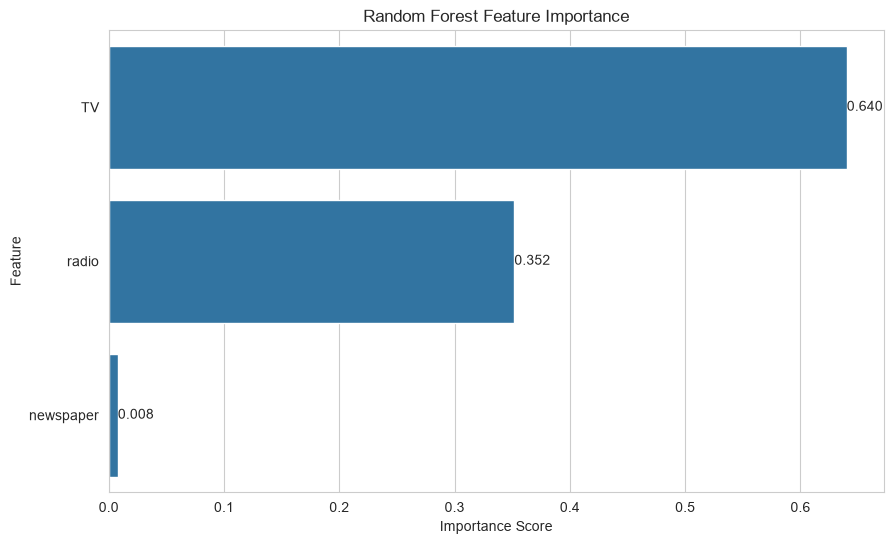

In [29]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

- The Random Forest Regressor model shows TV advertising is the most important predictor of sales with 64.02%, followed by radio with 35.18%, while newspaper had only 0.80% importance. Therefore, TV and radio advertising have the highest predictive value for sales.
- TV and Radio are both worth investing in.